# WP0 — SHADOW4 minimale, passo per passo

Sorgente monoenergetica → cristallo cilindrico Ge(880) → piani lungo la propagazione. Il *sample plane* è solo un piano di osservazione, non un campione fisico di Ag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from shadow4.beamline.optical_elements.crystals.s4_sphere_crystal import (
    S4SphereCrystal, S4SphereCrystalElement,
)
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
from syned.beamline.element_coordinates import ElementCoordinates
from syned.beamline.shape import Convexity, Direction, Rectangle

ENERGY_EV = 25_520.0
DISTANCE_M = 0.50
NRAYS = 100_000
MAX_PLOT_RAYS = 5_000

## 1. Sorgente

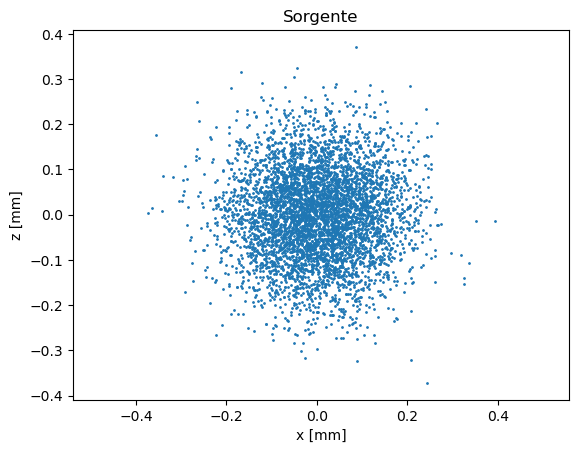

In [2]:
source = SourceGeometrical(nrays=NRAYS, seed=12345)
source.set_spatial_type_gaussian(sigma_h=1e-4, sigma_v=1e-4)
source.set_depth_distribution_off()
source.set_angular_distribution_flat(
    hdiv1=-0.06, hdiv2=0.06, vdiv1=-1e-5, vdiv2=1e-5
)
source.set_energy_distribution_singleline(ENERGY_EV, unit="eV")
incident = source.get_beam()

plt.scatter(1e3 * incident.get_column(1)[:MAX_PLOT_RAYS],
            1e3 * incident.get_column(3)[:MAX_PLOT_RAYS], s=1)
plt.xlabel("x [mm]")
plt.ylabel("z [mm]")
plt.title("Sorgente")
plt.axis("equal")
plt.show()

## 2. Cristallo Ge(880)

>>>>>> change_reference_system:  True True


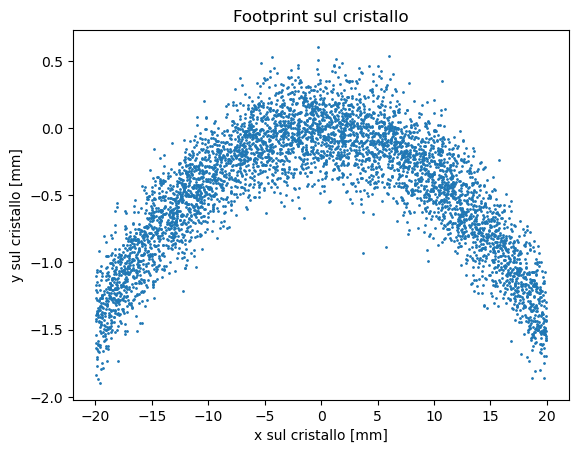

In [3]:
crystal = S4SphereCrystal(
    boundary_shape=Rectangle(-0.02, 0.02, -0.01, 0.01),
    material="Ge", miller_index_h=8, miller_index_k=8, miller_index_l=0,
    is_thick=1, thickness=1e-3, f_central=True, phot_cent=ENERGY_EV,
    material_constants_library_flag=0, radius=0.25, is_cylinder=True,
    cylinder_direction=Direction.SAGITTAL, convexity=Convexity.DOWNWARD,
)

post_crystal, footprint = S4SphereCrystalElement(
    optical_element=crystal,
    coordinates=ElementCoordinates(
        p=DISTANCE_M, q=0.0, angle_radial=0.0,
        angle_azimuthal=0.0, angle_radial_out=None,
    ),
    input_beam=incident,
).trace_beam()

good_fp = footprint.get_column(10) > 0
plt.scatter(1e3 * footprint.get_column(1)[good_fp][:MAX_PLOT_RAYS],
            1e3 * footprint.get_column(2)[good_fp][:MAX_PLOT_RAYS], s=1)
plt.xlabel("x sul cristallo [mm]")
plt.ylabel("y sul cristallo [mm]")
plt.title("Footprint sul cristallo")
plt.show()

## 3. Raggi lungo la propagazione dopo il cristallo

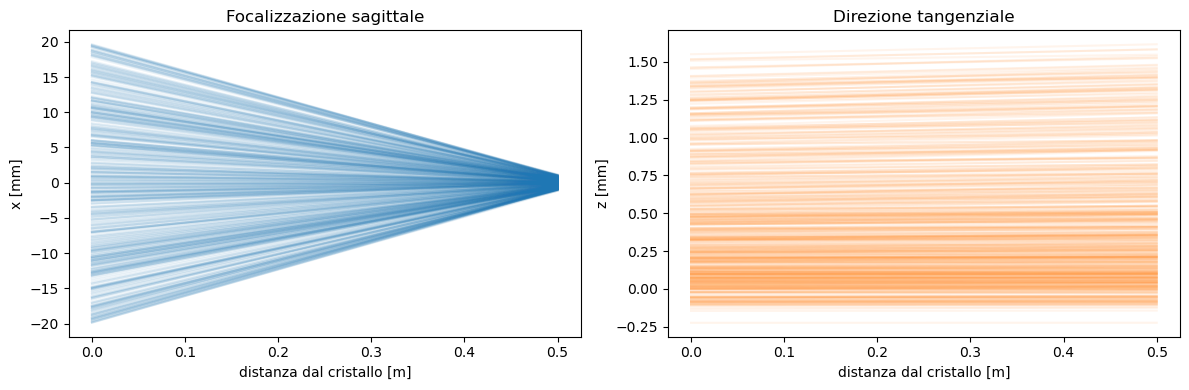

In [4]:
good = post_crystal.get_column(10) > 0
indices = np.flatnonzero(good)[:500]
x0, z0 = post_crystal.get_column(1), post_crystal.get_column(3)
vx, vy, vz = (post_crystal.get_column(i) for i in (4, 5, 6))
longitudinal = np.linspace(0.0, DISTANCE_M, 80)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in indices:
    axes[0].plot(longitudinal, 1e3 * (x0[i] + longitudinal * vx[i] / vy[i]),
                 color="tab:blue", alpha=0.08)
    axes[1].plot(longitudinal, 1e3 * (z0[i] + longitudinal * vz[i] / vy[i]),
                 color="tab:orange", alpha=0.08)
axes[0].set(xlabel="distanza dal cristallo [m]", ylabel="x [mm]",
            title="Focalizzazione sagittale")
axes[1].set(xlabel="distanza dal cristallo [m]", ylabel="z [mm]",
            title="Direzione tangenziale")
plt.tight_layout()
plt.show()

## 4. Profili a più distanze e piano del sample

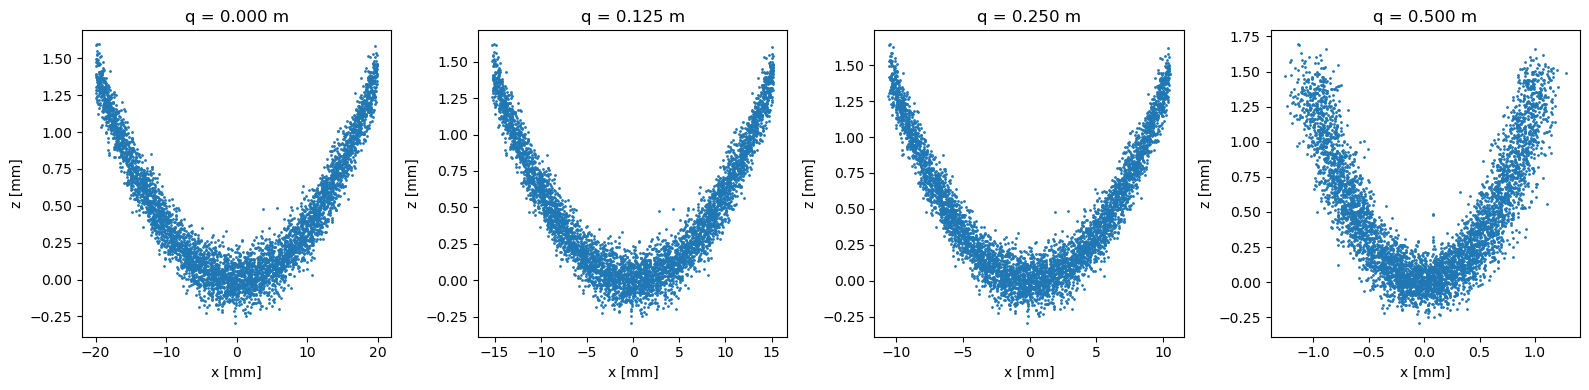

Raggi validi al sample plane: 66734


In [5]:
planes = [0.0, 0.25 * DISTANCE_M, 0.50 * DISTANCE_M, DISTANCE_M]
fig, axes = plt.subplots(1, len(planes), figsize=(16, 4))
for ax, distance in zip(axes, planes):
    beam = post_crystal.duplicate()
    beam.retrace(distance, resetY=True)
    mask = beam.get_column(10) > 0
    ax.scatter(1e3 * beam.get_column(1)[mask][:MAX_PLOT_RAYS],
               1e3 * beam.get_column(3)[mask][:MAX_PLOT_RAYS], s=1)
    ax.set(title=f"q = {distance:.3f} m", xlabel="x [mm]", ylabel="z [mm]")
plt.tight_layout()
plt.show()

beam_at_sample_plane = post_crystal.duplicate()
beam_at_sample_plane.retrace(DISTANCE_M, resetY=True)
print("Raggi validi al sample plane:",
      beam_at_sample_plane.get_number_of_rays(nolost=1))